In [98]:
import pandas as pd
import numpy as np
from nbconvert import export

In [99]:
df1 = pd.read_csv('../data/_roads3.csv')
# print(df1.head())

dfN1 = df1[df1['road'] == 'N1']

In [100]:
source_val = 0
sink_val = dfN1['chainage'].max()
source_row = dfN1[dfN1['chainage'] == source_val].head(1)
sink_row = dfN1[dfN1['chainage'] == sink_val].head(1)

In [101]:
df_proc = pd.concat([source_row, sink_row]).drop_duplicates(subset=['chainage', 'lrp']).sort_values('chainage').reset_index(drop=True)

In [102]:
df_proc

,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit..."


In [103]:
df_BMMS = pd.read_excel('../data/BMMS_overview.xlsx')

In [104]:
cols = [
    "road",
    "name",
    "LRPName",
    "length",
    "chainage",
    "lat",
    "lon",
    "condition",
]

bridges_BMMS = df_BMMS[cols].copy()
bridges_BMMS = bridges_BMMS[bridges_BMMS['road'] == 'N1']

In [105]:
bridges_BMMS.head(20)

,road,name,LRPName,length,chainage,lat,lon,condition
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A
5,N1,NAYABARI KASPUR BOX CULVERT,LRP011a,8.30,11.296,23.692360,90.540918,A
6,N1,KHAS PARA BOX CULVERT,LRP012a,9.30,12.239,23.688412,90.548559,A
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.10,12.253,23.688320,90.548650,A
8,N1,Madanpur Bridge.(L),LRP013a,27.50,12.660,23.685583,90.551208,A
9,N1,MADAN PUR (R),LRP013a,26.30,12.660,23.685583,90.551208,A


In [106]:
bridges_BMMS['name_clean'] = bridges_BMMS['name'].astype(str).str.replace(' ', '').str.upper()
bridges_BMMS['lat_round'] = bridges_BMMS['lat'].round(4)
bridges_BMMS['lon_round'] = bridges_BMMS['lon'].round(4)

In [107]:
bridges_BMMS.info()

<class 'pandas.core.frame.DataFrame'>
Index: 787 entries, 0 to 19382
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   road        787 non-null    object 
 1   name        787 non-null    object 
 2   LRPName     787 non-null    object 
 3   length      787 non-null    float64
 4   chainage    787 non-null    float64
 5   lat         787 non-null    float64
 6   lon         787 non-null    float64
 7   condition   787 non-null    object 
 8   name_clean  787 non-null    object 
 9   lat_round   787 non-null    float64
 10  lon_round   787 non-null    float64
dtypes: float64(6), object(5)
memory usage: 73.8+ KB


In [108]:
df_unique = bridges_BMMS.drop_duplicates(subset=['chainage', 'lat_round', 'lon_round'], keep='first')

In [109]:
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 628 entries, 0 to 19382
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   road        628 non-null    object 
 1   name        628 non-null    object 
 2   LRPName     628 non-null    object 
 3   length      628 non-null    float64
 4   chainage    628 non-null    float64
 5   lat         628 non-null    float64
 6   lon         628 non-null    float64
 7   condition   628 non-null    object 
 8   name_clean  628 non-null    object 
 9   lat_round   628 non-null    float64
 10  lon_round   628 non-null    float64
dtypes: float64(6), object(5)
memory usage: 58.9+ KB


In [110]:
df_unique.reset_index(drop=True, inplace=True)
df_unique

,road,name,LRPName,length,chainage,lat,lon,condition,name_clean,lat_round,lon_round
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A,.,23.6987,90.4589
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A,.,23.6947,90.4878
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A,KANCHPURBRIDGE.,23.7051,90.5232
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A,NOYAPARACULVERT,23.6944,90.5376
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A,ADUPURCULVERT,23.6943,90.5377
...,...,...,...,...,...,...,...,...,...,...,...
623,N1,MORICHIA,LRP394a,11.20,397.591,21.321109,92.088884,D,MORICHIA,21.3211,92.0889
624,N1,SHAPUR STEEL BEAM AND RCC SLAB,LRP396b,61.30,400.460,21.299745,92.097477,D,SHAPURSTEELBEAMANDRCCSLAB,21.2997,92.0975
625,N1,Balukhali Boro Bridge,LRP413b,15.40,417.290,21.188892,92.165877,D,BALUKHALIBOROBRIDGE,21.1889,92.1659
626,N1,Kata Khali Bridge,LRP421a,12.30,424.577,21.137612,92.168059,D,KATAKHALIBRIDGE,21.1376,92.1681


In [111]:
to_delete = []
for i, row in df_unique.iterrows():
    if i == 0:
        continue
    else:
        lat_lon_check = False
        length_check = False
        lrp_check = False
        lat_rounded = round(row['lat_round'],3)
        lon_rounded = round(row['lon_round'],3)
        if lat_rounded == round(df_unique.iloc[i-1]['lat_round'],3) and lon_rounded == round(df_unique.iloc[i-1]['lon_round'],3):
            lat_lon_check = True
        if float(row['length']) - float(df_unique.iloc[i-1]['length']) < 0.5:
            length_check = True
        if row['LRPName'][:6] == df_unique.iloc[i-1]['LRPName'][:6]:
            lrp_check = True
        if lat_lon_check and length_check and lrp_check:
            to_delete.append(i)
            
print(to_delete)
df_unique.loc[to_delete]

[4, 7, 28, 314, 370, 570]


,road,name,LRPName,length,chainage,lat,lon,condition,name_clean,lat_round,lon_round
4,N1,ADUPUR CULVERT,LRP010c,6.3,10.897,23.694302,90.537707,A,ADUPURCULVERT,23.6943,90.5377
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.1,12.253,23.688320,90.548650,A,DAWANBAGBOXCULVERT,23.6883,90.5486
28,N1,NOYAPARA,LRP033b,5.2,32.796,23.547625,90.669192,A,NOYAPARA,23.5476,90.6692
314,N1,NORTH-CONIAPARA,LRP389b,1.3,392.619,21.359728,92.079803,A,NORTH-CONIAPARA,21.3597,92.0798
370,N1,KHANGOR PRAMARY (2),LRP429c,1.2,432.924,21.086500,92.215111,A,KHANGORPRAMARY(2),21.0865,92.2151
570,N1,PANCHARA SLAB CULVERT,LRP385d,1.8,388.956,21.385641,92.070454,C,PANCHARASLABCULVERT,21.3856,92.0705


In [112]:
df_unique['model_type'] = 'bridge'



export_df = df_unique[['road', 'LRPName', 'model_type', 'name', 'lat', 'lon','length', 'condition']]
export_df.rename(columns={'LRPName': 'id'}, inplace=True)
export_df

C:\Users\niels\AppData\Local\Temp\ipykernel_29800\1203808769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['model_type'] = 'bridge'
C:\Users\niels\AppData\Local\Temp\ipykernel_29800\1203808769.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  export_df.rename(columns={'LRPName': 'id'}, inplace=True)


,road,id,model_type,name,lat,lon,length,condition
0,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A
1,N1,LRP004b,bridge,.,23.694664,90.487775,6.60,A
2,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A
3,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A
4,N1,LRP010c,bridge,ADUPUR CULVERT,23.694302,90.537707,6.30,A
...,...,...,...,...,...,...,...,...
623,N1,LRP394a,bridge,MORICHIA,21.321109,92.088884,11.20,D
624,N1,LRP396b,bridge,SHAPUR STEEL BEAM AND RCC SLAB,21.299745,92.097477,61.30,D
625,N1,LRP413b,bridge,Balukhali Boro Bridge,21.188892,92.165877,15.40,D
626,N1,LRP421a,bridge,Kata Khali Bridge,21.137612,92.168059,12.30,D


In [113]:
df_proc['model_type'] = 'source'
df_proc['length'] = 0
df_proc['condition'] = None
df_proc = df_proc[['road', 'lrp', 'model_type', 'name', 'lat', 'lon', 'length', 'condition']]
df_proc.rename(columns={'lrp':'id'}, inplace=True)


C:\Users\niels\AppData\Local\Temp\ipykernel_29800\728953760.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_proc.rename(columns={'lrp':'id'}, inplace=True)


In [114]:
df_proc

,road,id,model_type,name,lat,lon,length,condition
0,N1,LRPS,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None
1,N1,LRPE,source,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None


In [115]:
final_df = pd.DataFrame(columns=['road','id','model_type','name','lat','lon','length', 'condition'])
source = df_proc.iloc[[0]]
sink = df_proc.iloc[[-1]]
final_df = pd.concat([source, export_df, sink], ignore_index=True)
final_df

,road,id,model_type,name,lat,lon,length,condition
0,N1,LRPS,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None
1,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A
2,N1,LRP004b,bridge,.,23.694664,90.487775,6.60,A
3,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A
4,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A
...,...,...,...,...,...,...,...,...
625,N1,LRP396b,bridge,SHAPUR STEEL BEAM AND RCC SLAB,21.299745,92.097477,61.30,D
626,N1,LRP413b,bridge,Balukhali Boro Bridge,21.188892,92.165877,15.40,D
627,N1,LRP421a,bridge,Kata Khali Bridge,21.137612,92.168059,12.30,D
628,N1,LRP449f,bridge,DONMIA,20.925389,92.264945,2.70,D


In [116]:
final_df_with_links = pd.DataFrame(columns=['road','id','model_type','name','lat','lon','length', 'condition'])
for j, row in final_df.iterrows():
    if row['model_type'] == 'sink':
        break
    elif row['model_type'] == 'source':
        final_df_with_links.loc[len(final_df_with_links)] = row
    else:
        lat_link = row['lat'] - (row['lat'] - final_df.iloc[j-1]['lat']) / 2 
        lon_link = row['lon'] - (row['lon'] - final_df.iloc[j-1]['lon']) / 2 
        length = 0
        condition = None
        link = pd.Series({'road': 'N1', 'id': 'LRPxxx', 'model_type': 'link', 'name': 'LRP', 'lat': lat_link, 'lon': lon_link, 'length': length, 'condition': condition})
        final_df_with_links.loc[len(final_df_with_links)] = link
        final_df_with_links.loc[len(final_df_with_links)] = row

final_df_with_links.head(20)
        

,road,id,model_type,name,lat,lon,length,condition
0,N1,LRPS,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.0,None
1,N1,LRPxxx,link,LRP,23.702383,90.451097,0,None
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.3,A
3,N1,LRPxxx,link,LRP,23.696701,90.473318,0,None
4,N1,LRP004b,bridge,.,23.694664,90.487775,6.6,A
5,N1,LRPxxx,link,LRP,23.699862,90.505495,0,None
6,N1,LRP008b,bridge,Kanch pur Bridge.,23.70506,90.523214,394.23,A
7,N1,LRPxxx,link,LRP,23.699725,90.530394,0,None
8,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.3,A
9,N1,LRPxxx,link,LRP,23.694347,90.537641,0,None


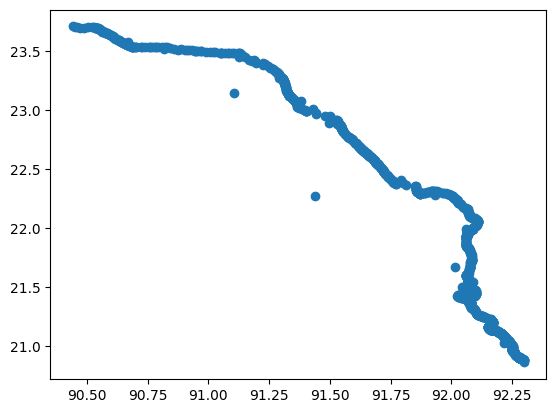

In [119]:
import matplotlib.pyplot as plt

plt.scatter(final_df_with_links['lon'], final_df_with_links['lat'])
plt.show()

In [118]:
#van de bridges moeten we de dubbelen eruit filteren
#als (L) erin staat, extra kolom met gap BS, als er (R) staat, extra kolom met BS
#deze keuze maken we, dus die moeten we ook uitleggen


#een punt toevoegen tussen de